# Assignment 3 Part A - Business-Level Clustering

## A1 - Data Acquisition and Cleaning

### Data Exploration

In [1]:
import json
import pandas as pd

with open("data/business-licences.geojson") as f:
    data = json.load(f)

df = pd.json_normalize([f["properties"] for f in data["features"]])

In [2]:
df.shape


(204301, 27)

In [3]:
df.columns


Index(['folderyear', 'licencersn', 'licencenumber', 'licencerevisionnumber',
       'businessname', 'businesstradename', 'status', 'issueddate',
       'expireddate', 'businesstype', 'businesssubtype', 'unit', 'unittype',
       'house', 'street', 'city', 'province', 'country', 'postalcode',
       'localarea', 'numberofemployees', 'feepaid', 'extractdate', 'geom',
       'geo_point_2d', 'geo_point_2d.lon', 'geo_point_2d.lat'],
      dtype='object')

In [4]:
df.head()


,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,...,country,postalcode,localarea,numberofemployees,feepaid,extractdate,geom,geo_point_2d,geo_point_2d.lon,geo_point_2d.lat
0,25,4637506,25-129785,00,(Anie Philip),None,Inactive,2024-11-25T21:02:01-08:00,2025-12-31,Long-term Rental,...,CA,V5R 3T5,Renfrew-Collingwood,0.0,94.0,2026-07-01T02:32:20-07:00,NaN,NaN,NaN,NaN
1,25,4637507,25-129786,00,(Tony Haughian),None,Issued,2024-11-18T09:52:13-08:00,2025-12-31,Long-term Rental,...,CA,V5T2N4,Mount Pleasant,0.0,226.0,2026-07-01T02:32:20-07:00,NaN,NaN,-123.088157,49.257736
2,25,4637508,25-129787,00,(Tony Haughian),None,Issued,2024-11-18T09:52:11-08:00,2025-12-31,Long-term Rental,...,CA,None,Mount Pleasant,0.0,275.0,2026-07-01T02:32:20-07:00,NaN,NaN,-123.089564,49.258053
3,25,4637511,25-129790,00,Simone Deborah Avram (Simone Avram),None,Issued,2025-01-13T15:28:19-08:00,2025-12-31,Long-term Rental,...,CA,V5V 2C6,Riley Park,0.0,188.0,2026-07-01T02:32:20-07:00,NaN,NaN,-123.096462,49.248896
4,25,4637516,25-129795,00,(William Squibb),None,Issued,2025-02-09T18:52:10-08:00,2025-12-31,Long-term Rental,...,CA,V5T 3Z3,Grandview-Woodland,0.0,437.0,2026-07-01T02:32:20-07:00,NaN,NaN,-123.066152,49.275461


In [5]:
df.dtypes

folderyear                object
licencersn                object
licencenumber             object
licencerevisionnumber     object
businessname              object
businesstradename         object
status                    object
issueddate                object
expireddate               object
businesstype              object
businesssubtype           object
unit                      object
unittype                  object
house                     object
street                    object
city                      object
province                  object
country                   object
postalcode                object
localarea                 object
numberofemployees        float64
feepaid                  float64
extractdate               object
geom                     float64
geo_point_2d             float64
geo_point_2d.lon         float64
geo_point_2d.lat         float64
dtype: object

In [6]:
df[["numberofemployees", "feepaid", "businesssubtype", "postalcode"]].isna().mean()


numberofemployees    0.000000
feepaid              0.369161
businesssubtype      0.894504
postalcode           0.466170
dtype: float64

Missingness varies a lot across these four columns. numberofemployees is complete. feepaid is missing for about 37% of records. businesssubtype is missing for about 89%, so it is too sparse to build a reliable type+subtype label from. postalcode is missing for about 47%, which limits how usable postal FSA would be as an area unit in Part B.

In [7]:
df["status"].value_counts(dropna=False)


status
Issued                  167179
Pending                  14791
Gone Out of Business     10535
Inactive                  6600
Cancelled                 5196
Name: count, dtype: int64

Issued accounts for 167,179 of 204,301 records, roughly 82%. The remaining statuses (Pending, Gone Out of Business, Inactive, Cancelled) do not represent currently valid licences, so they are candidates for exclusion.

In [8]:
df["businesstype"].value_counts()

businesstype
Long-term Rental                          45439
Health Care Professionals and Services    18766
General Contractor                        15908
Short-term Rental Operator                13419
Retail Dealer                              9458
                                          ...  
Urban Farm Class B                            8
Marine Service Station                        6
Adult Services                                4
Amusement Park                                3
Oil Gas and Other Fuels                       3
Name: count, Length: 94, dtype: int64

There are 94 business types with a very uneven distribution. A few categories dominate, led by Long-term Rental at over 45,000 records, while the smallest categories have fewer than ten. This long tail means the raw column needs consolidating before it can be used as a feature.

In [9]:
df["geo_point_2d.lat"].isna().mean()

np.float64(0.497535499092026)

About 50% of records have no latitude, and therefore no usable coordinates. Location clustering in A2 and the centroid map in B3 both require coordinates, and there is no sensible way to impute a location, so these rows cannot be used.

In [10]:
df["numberofemployees"].describe()


count    204301.000000
mean         10.021473
std          72.765566
min           0.000000
25%           0.000000
50%           1.000000
75%           4.000000
max        5876.000000
Name: numberofemployees, dtype: float64

The column is complete but heavily right skewed. The median is 1 employee while the mean is 10 and the maximum is 5,876. Most licences are very small operations with a small number of very large ones pulling the average up.

In [11]:
(df["numberofemployees"] == 0).mean()


np.float64(0.358294868845478)

About 36% of records report zero employees. Some of these are likely genuine, such as individual rental licences, but others may simply be unreported. The column still carries useful size information, though the zeros should be treated with some caution.

In [12]:
sub = df[df["geo_point_2d.lat"].notna() & (df["status"] == "Issued")]
print(sub.shape)
print(sub["feepaid"].isna().mean())

(85950, 27)
0.30810936591041305


Filtering to records that have coordinates and a status of Issued leaves 85,950 rows out of the original 204,301. Within that subset feepaid is still missing for about 31%, only slightly better than in the full data. Dropping those rows would cost another 26,000 records, so imputing the missing fees is the better trade.

In [13]:
sub["businesstype"].value_counts(normalize=True).cumsum().head(25)

businesstype
Health Care Professionals and Services           0.137510
Long-term Rental                                 0.256940
Retail Dealer                                    0.328400
Legal Services                                   0.389063
Restaurant                                       0.446294
Beauty Services                                  0.492158
Limited Service Food Establishment               0.536579
Business Support Services                        0.571111
Financial Services                               0.599058
Consulting and Management Services               0.626446
Real Estate Services                             0.650366
Retail Dealer - Food                             0.672903
General Contractor                               0.693729
Association or Society                           0.713775
Information Communication Technology             0.733636
Wholesale Dealer - Non-Food                      0.750599
Parking Area / Garage                            0.764491
H

The top 20 business types cover about 80% of the subset, and each category past that point adds less than 1%. Keeping the top 20 and grouping everything else as Other gives a manageable set of categories without losing much coverage.

The ranking has also shifted from the full dataset. Short-term Rental Operator was the fourth largest type overall but does not appear in the top 25 here, and General Contractor has dropped from third to thirteenth. The coordinate and status filters removed those categories more heavily than others, so the filtered data represents a somewhat different mix of industries than the raw file.

### Cleaning

In [14]:
df_clean = df[df["geo_point_2d.lat"].notna() & df["geo_point_2d.lon"].notna()].copy()


Rows without a latitude and longitude are dropped. A2 clusters businesses purely on location and B3 places each area at its centroid, so a record with no coordinates cannot be used in either. There is no reasonable way to guess a missing location. This removes about half the dataset, which is a large cut and worth keeping in mind when reading the results.

In [15]:
df_clean = df_clean[df_clean["status"] == "Issued"].copy()


Only licences with a status of Issued are kept. The other statuses cover licences that were never approved, were cancelled, or belong to businesses that have closed. Including them would mean clustering businesses that are not actually operating.

In [16]:
df_clean["feepaid_missing"] = df_clean["feepaid"].isna()
df_clean["feepaid"] = df_clean["feepaid"].fillna(df_clean["feepaid"].median())


Missing fees are filled with the median rather than dropped. About 31% of the remaining records have no fee recorded, and dropping them would cost another 26,000 rows on top of the coordinate loss. The median is used instead of the mean because the fee values are skewed. A flag column records which rows were imputed.

In [17]:
top20 = df_clean["businesstype"].value_counts().head(20).index
df_clean["businesstype_grouped"] = df_clean["businesstype"].where(
    df_clean["businesstype"].isin(top20), "Other"
)

The top 20 business types are kept and everything else is grouped as Other. These 20 cover about 80% of the records, and every category beyond that adds less than 1% each. Leaving all 94 categories in place would create a very wide and mostly empty feature matrix once encoded. The top 20 are counted after filtering, not before, so the ranking reflects the data actually being used.

In [18]:
df_clean["issueddate"] = pd.to_datetime(
    df_clean["issueddate"], format="ISO8601", utc=True
).dt.tz_localize(None)
df_clean["expireddate"] = pd.to_datetime(df_clean["expireddate"], errors="coerce")


issueddate and expireddate are converted to datetime so that licence duration can be calculated in A3. issueddate includes a timezone offset that changes with daylight saving, so it is parsed as UTC and then stripped of the timezone. This is needed because expireddate has no timezone, and the two columns cannot be subtracted unless they match.

In [19]:
df_clean["licencerevisionnumber"] = pd.to_numeric(
    df_clean["licencerevisionnumber"], errors="coerce"
)

licencerevisionnumber is stored as text and is converted to a number so it can be used as a lifecycle feature.

In [20]:
print(df_clean.shape)
print(df_clean["businesstype_grouped"].value_counts())

(85950, 29)
businesstype_grouped
Other                                            17243
Health Care Professionals and Services           11819
Long-term Rental                                 10265
Retail Dealer                                     6142
Legal Services                                    5214
Restaurant                                        4919
Beauty Services                                   3942
Limited Service Food Establishment                3818
Business Support Services                         2968
Financial Services                                2402
Consulting and Management Services                2354
Real Estate Services                              2056
Retail Dealer - Food                              1937
General Contractor                                1790
Association or Society                            1723
Information Communication Technology              1707
Wholesale Dealer - Non-Food                       1458
Parking Area / Garage           

In [21]:
print(df_clean["expireddate"].isna().sum())
print(df_clean["issueddate"].isna().sum())
print((df_clean["expireddate"] - df_clean["issueddate"]).dt.days.describe())

148
147
count    85802.000000
mean       349.901273
std         81.582944
min       -354.000000
25%        344.000000
50%        377.000000
75%        399.000000
max        601.000000
dtype: float64


Note a negative min for duration. Data entry error. Let's check how many of these there are.

In [22]:
dur = (df_clean["expireddate"] - df_clean["issueddate"]).dt.days
print((dur < 0).sum())
print(dur[dur < 0].describe())

66
count     66.000000
mean     -35.772727
std       77.068161
min     -354.000000
25%      -22.000000
50%       -7.000000
75%       -2.250000
max       -1.000000
dtype: float64


66. Not too many. We'll drop these. 

In [23]:
df_clean["licence_duration"] = (df_clean["expireddate"] - df_clean["issueddate"]).dt.days
df_clean = df_clean[df_clean["licence_duration"] > 0].copy()
print(df_clean.shape)

(85689, 30)


There's the fully cleaned set. We'll save it now for user later. 

In [24]:
df_clean.to_parquet("data/businesses_clean.parquet")

## A2 - Location-only clustering: K-means vs DBSCAN

### K-Means

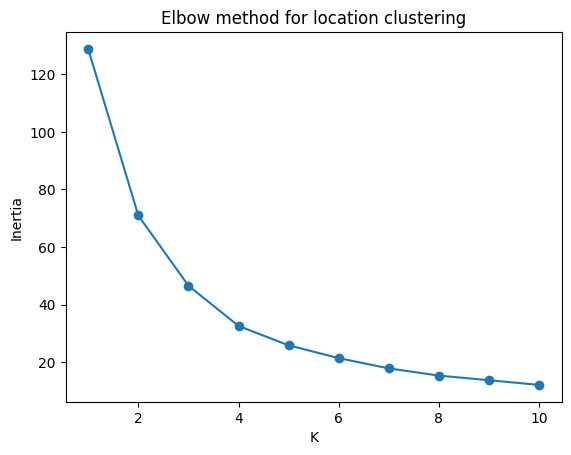

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

coords = df_clean[["geo_point_2d.lon", "geo_point_2d.lat"]].values

inertias = []
ks = range(1, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords)
    inertias.append(km.inertia_)

plt.plot(ks, inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow method for location clustering")
plt.show()

Inertia drops steeply from K=1 to K=4 and then flattens, with almost no improvement past K=5. K=5 was chosen as the point where adding clusters stops buying much. The curve is smooth rather than sharply bent, which is expected for geographic data. Businesses are spread continuously across a city rather than sitting in separate groups, so there is no single obviously correct K.

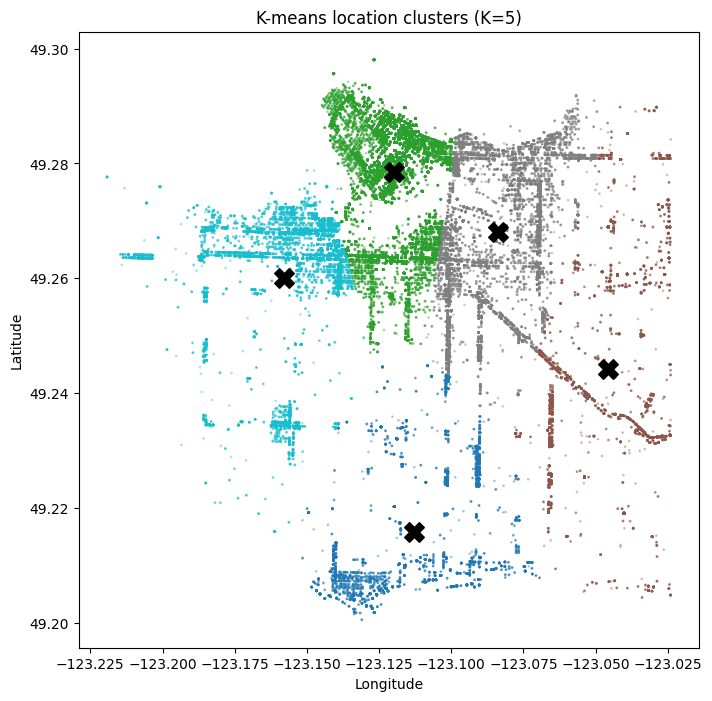

In [26]:
from sklearn.cluster import DBSCAN

km = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean["kmeans_geo"] = km.fit_predict(coords)

plt.figure(figsize=(8, 8))
plt.scatter(coords[:, 0], coords[:, 1], c=df_clean["kmeans_geo"],
            cmap="tab10", s=1, alpha=0.3)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c="black", marker="X", s=200)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-means location clusters (K=5)")
plt.show()

The five K-means clusters line up closely with parts of Vancouver. The green cluster covers the downtown peninsula and the West End and is by far the densest. Cyan covers the west side running out through Kitsilano to Point Grey and Dunbar. Grey covers the east central area around Mount Pleasant and Commercial Drive. Brown covers the far east and southeast around Renfrew-Collingwood and Killarney. Blue covers south Vancouver around Marpole and Sunset.

Some finer structure is visible inside the clusters. The diagonal line of businesses running southeast is Kingsway.

The clusters are five wedges with straight boundaries. This is a direct result of how K-means works. It assigns every point to the nearest centre, so it splits the map into regions of roughly similar size and every business ends up in a cluster whether or not it sits in a real commercial district. The boundaries fall in places that mean nothing on the ground.

### DBSCAN

In [27]:
db = DBSCAN(eps=0.003, min_samples=50)
df_clean["dbscan_geo"] = db.fit_predict(coords)

print(df_clean["dbscan_geo"].value_counts().head(10))
print("noise share:", (df_clean["dbscan_geo"] == -1).mean())

dbscan_geo
 0     72153
 2      4270
 7      1545
-1      1277
 20     1212
 3       946
 1       566
 9       407
 8       293
 13      258
Name: count, dtype: int64
noise share: 0.014902729638576714


In [28]:
db = DBSCAN(eps=0.001, min_samples=100)
df_clean["dbscan_geo"] = db.fit_predict(coords)

print(df_clean["dbscan_geo"].nunique())
print(df_clean["dbscan_geo"].value_counts().head(10))
print("noise share:", (df_clean["dbscan_geo"] == -1).mean())

104
dbscan_geo
 1     25737
-1     22456
 5      3474
 38     3462
 3      2003
 6      1778
 12     1370
 28     1165
 30     1155
 16     1095
Name: count, dtype: int64
noise share: 0.2620639755394508


eps=0.003, min_samples=50   ->  84% in one cluster, 1.5% noise, too permissive
eps=0.001, min_samples=100  ->  30% largest, 26% noise, 104 clusters

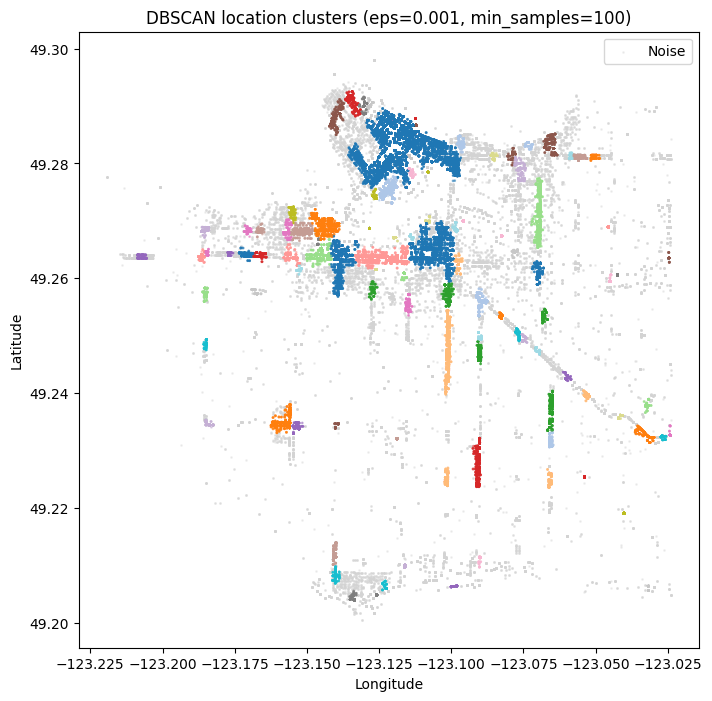

In [29]:
plt.figure(figsize=(8, 8))
noise = df_clean["dbscan_geo"] == -1
plt.scatter(coords[noise, 0], coords[noise, 1],
            c="lightgrey", s=1, alpha=0.3, label="Noise")
plt.scatter(coords[~noise, 0], coords[~noise, 1],
            c=df_clean.loc[~noise, "dbscan_geo"], cmap="tab20", s=1, alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN location clusters (eps=0.001, min_samples=100)")
plt.legend()
plt.show()

NOTE: Colours repeat across clusters because there are far more clusters than distinct colours. Two areas sharing a colour are not necessarily the same cluster.

DBSCAN was tuned by trial and error. At eps=0.003 with min_samples=50, one cluster absorbed 84% of businesses and only 1.5% were marked as noise, since at a radius of roughly 300 metres almost the whole city chains together. Reducing eps to 0.001 and raising min_samples to 100 gave a more useful result: 104 clusters, the largest holding 30% of points, and 26% marked as noise.

The two methods find different things. Both methods identify the downtown peninsula as the densest concentration, and it comes out as a single coherent group under either approach. K-means divides the whole map into five large regions. DBSCAN ignores most of the map and picks out small dense pockets, which turn out to be commercial strips. The vertical clusters follow arterials like Main and Victoria, the horizontal band is Broadway, and the largest cluster is downtown, which stays connected because the businesses there never thin out enough to break the chain. The grey noise points are mostly home based businesses spread through residential areas.

This comes down to what each algorithm assumes. K-means assumes roughly round clusters of similar size and forces every point into one, so its boundaries fall in places that mean nothing on the ground. DBSCAN assumes clusters are dense areas of any shape and lets points belong to nothing, which matches commercial geography better since real business districts are strips along streets rather than circles.

## A3 - Feature-based clustering: Size, Industry, Lifecycle

In [30]:
import numpy as np

# Size
feat = df_clean[["numberofemployees", "feepaid"]].copy()

# Lifecycle
feat["licence_duration"] = df_clean["licence_duration"]
feat["licencerevisionnumber"] = df_clean["licencerevisionnumber"]

# Month issued, cyclically encoded so December and January are close
month = df_clean["issueddate"].dt.month
feat["month_sin"] = np.sin(2 * np.pi * month / 12)
feat["month_cos"] = np.cos(2 * np.pi * month / 12)

# Industry, one-hot encoded
industry = pd.get_dummies(df_clean["businesstype_grouped"], prefix="type")
feat = pd.concat([feat, industry], axis=1)

print(feat.shape)
print(feat.isna().sum()[feat.isna().sum() > 0])

(85689, 27)
Series([], dtype: int64)


In [31]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(feat)

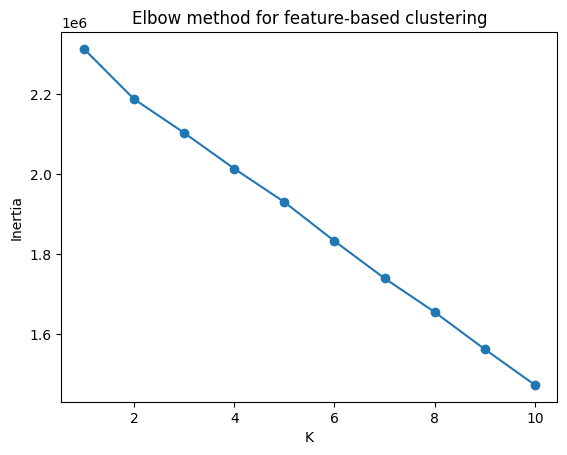

In [32]:
inertias = []
ks = range(1, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(ks, inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow method for feature-based clustering")
plt.show()

In [33]:
from sklearn.metrics import silhouette_score

idx = np.random.RandomState(42).choice(len(X), 10000, replace=False)
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    print(k, round(silhouette_score(X[idx], km.labels_[idx]), 3))

3 0.141
4 0.176
5 0.093
6 0.159
7 0.197
8 0.187


The elbow plot for the feature space is close to a straight line, with inertia falling by a similar amount at every K and no point where the returns drop off. Silhouette scores were checked as a second source of evidence and were low across the board, ranging from 0.09 to 0.20, with the best at K=7. Both results point the same way. There is no strong natural grouping in this feature space, so K=7 was chosen as the best of a set of weak options rather than a clearly correct answer.

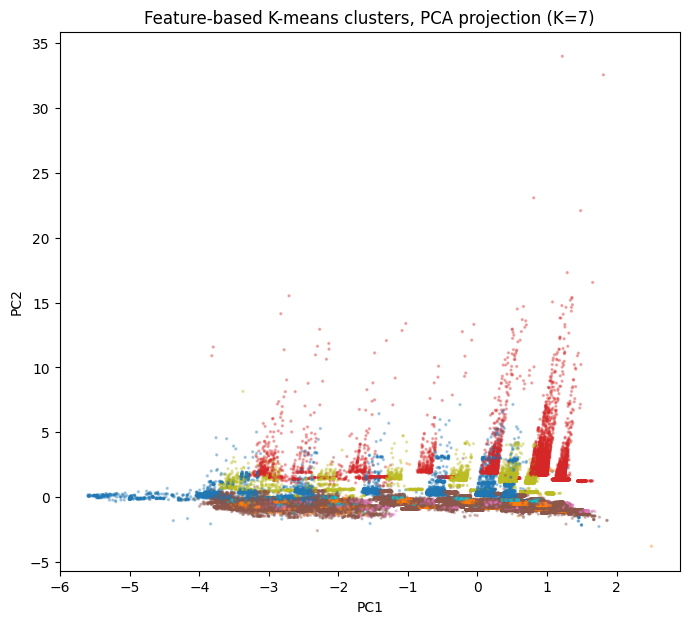

[0.06778338 0.05214375]
0.11992712839736294


In [34]:
from sklearn.decomposition import PCA

km = KMeans(n_clusters=7, random_state=42, n_init=10)
df_clean["kmeans_feat"] = km.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_clean["kmeans_feat"],
            cmap="tab10", s=2, alpha=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Feature-based K-means clusters, PCA projection (K=7)")
plt.show()

print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

The first two components explain only 12% of the variance, so the 2D plot is a rough summary of a 27 dimensional space and points appearing close together are not necessarily similar. The visible striping comes from the one hot industry columns, which take only the values 0 or 1 and so shift points by fixed amounts rather than spreading them continuously. The points fanning upward are the businesses with unusually high employee counts and fees.

In [35]:
profile = feat.groupby(df_clean["kmeans_feat"]).mean()

# z-scores relative to the overall mean, for the numeric features
num_cols = ["numberofemployees", "feepaid", "licence_duration", "licencerevisionnumber"]
z = (profile[num_cols] - feat[num_cols].mean()) / feat[num_cols].std()
print(df_clean["kmeans_feat"].value_counts().sort_index())
print(z.round(2))

# dominant industry per cluster
type_cols = [c for c in feat.columns if c.startswith("type_")]
print(profile[type_cols].idxmax(axis=1))
print(profile[type_cols].max(axis=1).round(2))

kmeans_feat
0    16958
1     6139
2    10317
3    40213
4     5213
5     4912
6     1937
Name: count, dtype: int64
             numberofemployees  feepaid  licence_duration  \
kmeans_feat                                                 
0                         0.05    -0.00             -0.14   
1                        -0.08    -0.20              0.07   
2                        -0.16     0.75              0.17   
3                         0.02    -0.19             -0.01   
4                         0.08    -0.21              0.21   
5                         0.03     0.47             -0.07   
6                        -0.10    -0.16             -0.04   

             licencerevisionnumber  
kmeans_feat                         
0                            -0.08  
1                             0.10  
2                             0.04  
3                            -0.00  
4                             0.06  
5                             0.02  
6                             0.01  
km

In [36]:
df_clean[df_clean["kmeans_feat"] == 3]["businesstype_grouped"].value_counts()

businesstype_grouped
Health Care Professionals and Services           11813
Beauty Services                                   3939
Limited Service Food Establishment                3818
Business Support Services                         2968
Financial Services                                2402
Consulting and Management Services                2354
Real Estate Services                              2055
General Contractor                                1788
Association or Society                            1723
Information Communication Technology              1707
Wholesale Dealer - Non-Food                       1458
Parking Area / Garage                             1191
Health Care Facility                              1042
Architectural and Engineering Services             983
Non-Food Manufacturer Assembler and Processor      972
Name: count, dtype: int64

Profiling the clusters shows they are almost entirely defined by industry. K-means gave dedicated clusters to the six categories and swept the remaining fifteen into one bucket.

Size and lifecycle contributed almost nothing. Across all seven clusters the z-scores for employees, licence duration and revision number stay within roughly 0.2 of the overall average. Only fee paid stands out, with two clusters elevated at 0.75 and 0.47. In other words the algorithm did not find groups of large businesses versus small ones, or long licences versus short ones. It grouped by category alone.

This happens because 21 of the 27 features are one hot industry indicators. Two businesses of different types differ on two of those columns regardless of anything else, and after scaling that difference outweighs the more gradual variation in size and lifecycle. The feature set was built to describe three things but in practice one of them decides the outcome.

This is different from A2. The geographic clustering produced groups that map onto real places, and the split between downtown, the west side and south Vancouver is meaningful even though the boundaries are arbitrary. The feature based clustering mostly reproduces a column that already existed in the data. Knowing that a business is in the Restaurant cluster tells you nothing that the businesstype field did not already say.

The two are answering different questions. A2 asks where businesses are, and location has real continuous structure. A3 asks what businesses are like, and the strongest signal available is the category label itself.

# Assignment 3 Part B - Neighbourhood/Zipcode Similarity Explorer

In [37]:
print(df_clean["localarea"].isna().mean())
print(df_clean["localarea"].nunique())
print(df_clean["localarea"].value_counts())

0.0
23
localarea
Downtown                    26769
Fairview                    10241
Mount Pleasant               6325
Kitsilano                    6068
West End                     5036
Grandview-Woodland           4374
Strathcona                   3895
Kensington-Cedar Cottage     3629
Marpole                      3210
Renfrew-Collingwood          2714
Sunset                       2572
Riley Park                   2351
Hastings-Sunrise             1943
Victoria-Fraserview          1025
Kerrisdale                   1019
Arbutus-Ridge                 915
West Point Grey               781
Killarney                     727
Dunbar-Southlands             631
South Cambie                  577
Oakridge                      527
Shaughnessy                   356
Out of Town                     4
Name: count, dtype: int64


In [38]:
# business counts per area
counts = df_clean["localarea"].value_counts()
print(counts.tail(10))

localarea
Victoria-Fraserview    1025
Kerrisdale             1019
Arbutus-Ridge           915
West Point Grey         781
Killarney               727
Dunbar-Southlands       631
South Cambie            577
Oakridge                527
Shaughnessy             356
Out of Town               4
Name: count, dtype: int64


In [39]:
# composition matrix
keep = counts[counts >= 100].index   # adjust cutoff 
comp = pd.crosstab(
    df_clean.loc[df_clean["localarea"].isin(keep), "localarea"],
    df_clean.loc[df_clean["localarea"].isin(keep), "businesstype_grouped"],
    normalize="index"
) * 100

print(comp.shape)
comp.round(1).head()

(22, 21)


businesstype_grouped,Architectural and Engineering Services,Association or Society,Beauty Services,Business Support Services,Consulting and Management Services,Financial Services,General Contractor,Health Care Facility,Health Care Professionals and Services,Information Communication Technology,...,Limited Service Food Establishment,Long-term Rental,Non-Food Manufacturer Assembler and Processor,Other,Parking Area / Garage,Real Estate Services,Restaurant,Retail Dealer,Retail Dealer - Food,Wholesale Dealer - Non-Food
localarea,,,,,,,,,,,,,,,,,,,,,
Arbutus-Ridge,0.0,0.7,6.6,1.6,3.0,1.7,0.9,3.4,21.0,0.1,...,4.6,14.0,0.0,15.1,0.5,4.6,6.4,9.7,3.4,0.4
Downtown,1.6,2.0,4.6,6.8,5.4,5.4,2.1,0.7,9.5,4.6,...,3.9,1.5,0.1,17.6,1.5,3.8,5.0,5.7,1.3,0.7
Dunbar-Southlands,0.5,0.3,5.1,2.4,1.9,1.6,2.7,0.5,20.8,0.5,...,8.4,5.1,0.0,26.0,0.5,2.9,3.6,11.7,4.9,0.0
Fairview,1.9,1.3,3.4,3.6,2.7,3.0,2.5,2.0,28.8,1.1,...,2.7,11.0,0.2,15.1,2.4,3.6,3.2,7.3,1.0,0.9
Grandview-Woodland,0.3,2.6,3.2,0.7,0.6,0.3,1.8,0.7,7.0,0.3,...,5.2,23.2,4.5,30.0,0.2,0.5,6.7,5.4,3.6,3.0


In [40]:
centroids = df_clean.groupby("localarea")[["geo_point_2d.lon", "geo_point_2d.lat"]].mean()

In [41]:
print(comp.shape)

(22, 21)


localarea was chosen as the unit of analysis over postal FSA. It is complete in the cleaned data with no missing values, while postalcode is missing for about 47% of records, so FSA would have covered only around half the businesses and biased the result toward whichever areas record postal codes more reliably.

Each area is described by the percentage of its businesses falling into each of the 21 consolidated business types. Row normalising means a neighbourhood with 27,000 businesses and one with 400 are compared on the same scale, so the clustering responds to the mix of business types rather than to sheer size.

A minimum count threshold was considered but does not bind here. The smallest named neighbourhood, Shaughnessy, has 356 businesses, which is more than enough for stable percentages. The only row excluded is Out of Town, which has 4 records and is not a neighbourhood at all but a catch-all for addresses outside the city. That leaves 22 areas.

The matrix is left on its original 0 to 100 scale rather than standardised. All columns are already in the same units and represent shares of the same total, so scaling would distort the meaning by making rare business types count as much as common ones.

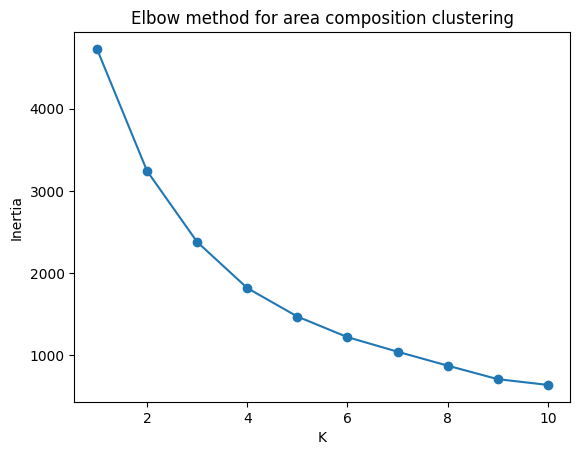

In [42]:
from sklearn.decomposition import PCA

X_area = comp.values

inertias = []
ks = range(1, 11)
for k in ks:
    inertias.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_area).inertia_)

plt.plot(ks, inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow method for area composition clustering")
plt.show()

In [43]:
km_area = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = km_area.fit_predict(X_area)

area_clusters = pd.DataFrame({"cluster": labels}, index=comp.index)
for c in sorted(area_clusters["cluster"].unique()):
    print(f"Cluster {c}:", list(area_clusters[area_clusters["cluster"] == c].index))

Cluster 0: ['Arbutus-Ridge', 'Dunbar-Southlands', 'Fairview', 'Kensington-Cedar Cottage', 'Kerrisdale', 'Killarney', 'Oakridge', 'Renfrew-Collingwood', 'Riley Park', 'Victoria-Fraserview']
Cluster 1: ['Kitsilano', 'Shaughnessy', 'South Cambie', 'West End']
Cluster 2: ['Downtown']
Cluster 3: ['Grandview-Woodland', 'Hastings-Sunrise', 'Marpole', 'Mount Pleasant', 'Strathcona', 'Sunset', 'West Point Grey']


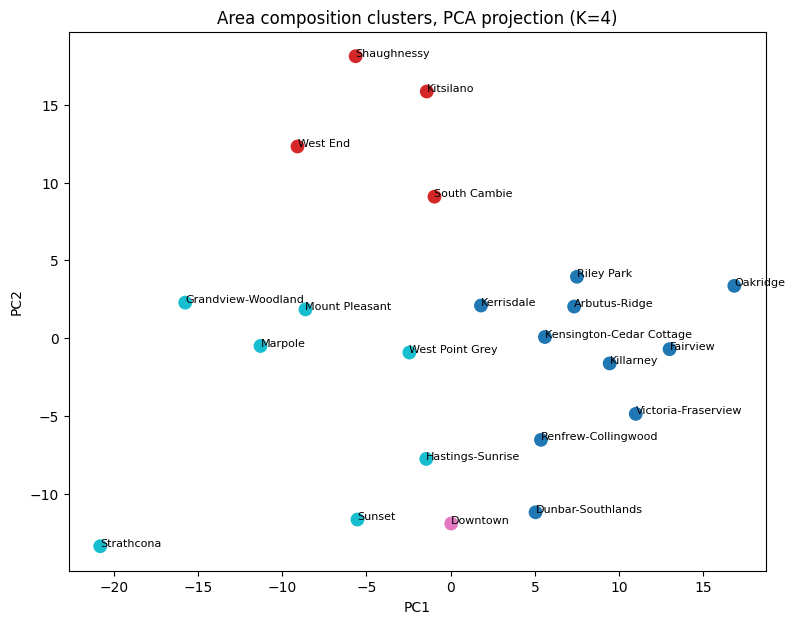

[0.40156173 0.33213966] 0.7337013829191101


In [44]:
pca_area = PCA(n_components=2)
X_area_pca = pca_area.fit_transform(X_area)

plt.figure(figsize=(9, 7))
plt.scatter(X_area_pca[:, 0], X_area_pca[:, 1], c=labels, cmap="tab10", s=80)
for i, name in enumerate(comp.index):
    plt.annotate(name, (X_area_pca[i, 0], X_area_pca[i, 1]), fontsize=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Area composition clusters, PCA projection (K=4)")
plt.show()

print(pca_area.explained_variance_ratio_, pca_area.explained_variance_ratio_.sum())

In [45]:
comp_prof = comp.copy()
comp_prof["cluster"] = labels

# mean composition
cluster_means = comp_prof.groupby("cluster").mean()

# types
overall = comp.mean()
diff = (cluster_means - overall).round(1)

for c in sorted(cluster_means.index):
    print(f"\nCluster {c}")
    print("above average:", diff.loc[c].sort_values(ascending=False).head(4).to_dict())
    print("below average:", diff.loc[c].sort_values().head(3).to_dict())


Cluster 0
above average: {'Health Care Professionals and Services': 6.5, 'Retail Dealer': 1.4, 'Beauty Services': 1.0, 'Limited Service Food Establishment': 0.9}
below average: {'Long-term Rental': -3.7, 'Other': -3.0, 'Wholesale Dealer - Non-Food': -1.1}

Cluster 1
above average: {'Long-term Rental': 13.0, 'Restaurant': 1.8, 'Financial Services': 0.9, 'Legal Services': 0.6}
below average: {'Other': -4.5, 'Health Care Professionals and Services': -3.2, 'Retail Dealer': -1.5}

Cluster 2
above average: {'Legal Services': 14.3, 'Business Support Services': 5.1, 'Information Communication Technology': 3.9, 'Consulting and Management Services': 3.9}
below average: {'Long-term Rental': -13.6, 'Health Care Professionals and Services': -7.0, 'Other': -2.9}

Cluster 3
above average: {'Other': 7.3, 'Wholesale Dealer - Non-Food': 2.5, 'Non-Food Manufacturer Assembler and Processor': 2.1, 'General Contractor': 1.2}
below average: {'Health Care Professionals and Services': -6.5, 'Legal Services': 

In [46]:
print(comp.loc[["Shaughnessy", "West Point Grey"]].round(1).T.sort_values("Shaughnessy", ascending=False).head(8))

localarea                               Shaughnessy  West Point Grey
businesstype_grouped                                                
Long-term Rental                               32.3             15.4
Other                                          15.2             25.0
Health Care Professionals and Services         13.8             14.9
Restaurant                                      7.6              9.0
Financial Services                              5.1              1.2
Retail Dealer                                   4.2             11.9
Real Estate Services                            3.7              0.4
Beauty Services                                 3.4              5.8


In [47]:
print(comp.loc["West Point Grey", ["Wholesale Dealer - Non-Food",
                                    "Non-Food Manufacturer Assembler and Processor",
                                    "General Contractor"]].round(1))
print(comp[["Wholesale Dealer - Non-Food",
            "Non-Food Manufacturer Assembler and Processor"]].mean().round(1))

businesstype_grouped
Wholesale Dealer - Non-Food                      0.0
Non-Food Manufacturer Assembler and Processor    0.6
General Contractor                               0.8
Name: West Point Grey, dtype: float64
businesstype_grouped
Wholesale Dealer - Non-Food                      1.7
Non-Food Manufacturer Assembler and Processor    1.2
dtype: float64


The four clusters correspond to recognisable economic roles rather than arbitrary groupings.

Cluster 0 contains ten areas including Kerrisdale, Arbutus-Ridge, Riley Park, Renfrew-Collingwood and Killarney. Health care is 6.5 points above the city average, followed by retail, beauty services and takeout food, while long-term rental is below average. These are residential neighbourhoods whose businesses exist to serve the people living in them: clinics, dentists, salons and local shops.

Cluster 1 contains Kitsilano, West End, Shaughnessy and South Cambie. Long-term rental is 13 points above average, with restaurants slightly elevated. These are areas where a large share of licences are for rental housing rather than commercial activity.

Cluster 2 is Downtown on its own. Legal services are 14.3 points above average, with business support, ICT and consulting all elevated, and long-term rental 13.6 points below. It is the only area in the city where the business mix is dominated by offices and professional firms rather than housing or neighbourhood retail. A cluster of one is a reasonable outcome here, since no other area resembles it.

Cluster 3 contains Strathcona, Mount Pleasant, Grandview-Woodland, Hastings-Sunrise, Marpole, Sunset and West Point Grey. Wholesale dealing, non-food manufacturing and general contracting are all above average while health care is 6.5 points below. Most of these areas hold Vancouver's remaining industrial land, though as noted below not every member fits that description.

The most notable finding is that business similarity does not follow geography. Cluster 0 groups Kerrisdale, Arbutus-Ridge and Dunbar-Southlands on the west side with Renfrew-Collingwood, Killarney and Victoria-Fraserview on the east side. These neighbourhoods sit at opposite ends of the city and differ substantially in income and housing stock, but their business mixes are close because they play the same role: residential areas served by local businesses. Cluster 1 is similarly scattered, running from the West End on the downtown peninsula out to Kitsilano.

Two memberships are less expected. Shaughnessy is one of the wealthiest single-family areas in the city yet clusters with dense rental neighbourhoods. Its composition explains why: 32.3% of its licences are long-term rental, the highest share of any area in the cluster, which likely reflects secondary suites and laneway houses rather than apartment buildings.

West Point Grey is harder to defend. It groups with the industrial areas, but its own composition shows no industrial character. What places it there is the Other bucket at 25.0%, the highest of any area. Since Other is a category created during cleaning by collapsing the 74 smallest business types, this grouping is driven by an artifact of that decision rather than by anything real about the neighbourhood. A larger top N would likely move it.

Two limitations: First, there are 22 areas and 21 features, so the sample is barely larger than the dimensionality. The clusters are stable across nearby values of K but should not be treated as strongly established. Second, the Other bucket is the largest single feature separating cluster 3, and Other is a category this analysis created during cleaning rather than one the data provides. Part of what distinguishes that cluster is therefore an artifact of the top 20 cutoff.